# GPROF-NN GMI

This notebook demonstrates how to run the GPROF-NN retrieval on GMI observations.


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

## Input Data

The GPROF-NN retrieval for GMI can be run on either GPM L1C-R files or preprocessed files, which contain the observations together with ancillary data. For this example, we will use the ``download_test_file`` function to download example input files that are available from the [GPROF-NN Hugging Face](hf.co/simonpf/gprof_nn) repository.


In [3]:
from gprof_nn.download import download_test_file

l1c_file = download_test_file("gmi", "l1c")
pp_file = download_test_file("gmi", "preprocessor")

## Running the Retrieval

The easiest way to run the retrieval is using the ``run_retrieval`` function from the ``gprof_nn.retrieval`` module. The ``run_retrieval`` function runs the retrieval on one or multiple input files. The function returns a list of ``xarray.Dataset`` objects containing the results for every provided input file. In this case, there is only one input file, so the list only contains on element.

> NOTE: When running the retrieval on L1C files, the ``run_retrieval`` function will check if a preprocessor binary is available on your system. If that is not the case, it will run the retrieval without ancillary data, which leads to a slight decrease in retrieval accuracy.

In [7]:
from gprof_nn.retrieval import run_retrieval


results = run_retrieval(pp_file)
result = results[0]
result

Output()

[04/06/26 09:09:25] INFO     INFO:gprof_nn.retrieval:Applying post-boost adjustment for sensor     ]8;id=265823;file:///home/simon/src/gprof_nn/src/gprof_nn/retrieval.py\retrieval.py]8;;\:]8;id=520715;file:///home/simon/src/gprof_nn/src/gprof_nn/retrieval.py#233\233]8;;\
                             'GMI'.                                                                                

<xarray.Dataset> Size: 24MB
Dimensions:                       (scans: 187, pixels: 221, levels: 28)
Dimensions without coordinates: scans, pixels, levels
Data variables: (12/35)
    pixel_status                  (scans, pixels) float64 331kB 0.0 0.0 ... 0.0
    quality_flag                  (scans, pixels) float64 331kB 1.0 1.0 ... 1.0
    scan_time                     (scans) datetime64[ns] 1kB 2024-10-08T06:10...
    longitude                     (scans, pixels) float32 165kB -99.45 ... -8...
    latitude                      (scans, pixels) float32 165kB 32.98 ... 17.47
    total_column_water_vapor      (scans, pixels) float32 165kB 22.84 ... 50.5
    ...                            ...
    rain_water_content            (scans, pixels, levels) float32 5MB 3.019e-...
    snow_water_content            (scans, pixels, levels) float32 5MB 1.205e-...
    cloud_water_content           (scans, pixels, levels) float32 5MB 0.00034...
    latent_heating                (scans, pixels, levels) float32 5MB -2.527e...
    precipitation_flag            (scans, pixels) bool 41kB False ... False
    frozen_precip                 (scans, pixels) float64 331kB 0.0 ... 8.27e-10
Attributes:
    ancillary_config:  CLI
    algorithm:         gprof_nn, version 0.8.14

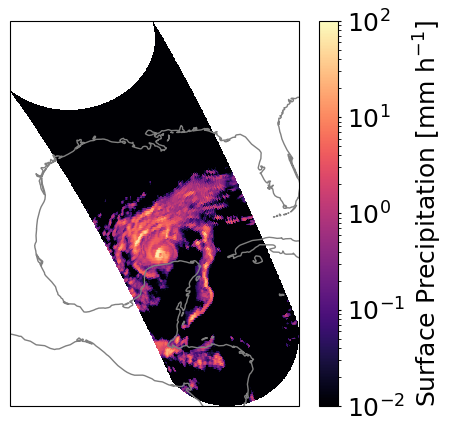

In [32]:
from gprof_nn.plotting import set_style, add_ticks
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LogNorm
import cartopy.crs as ccrs

set_style()
crs = ccrs.PlateCarree()

lons = result.longitude.data
lats = result.latitude.data
sp = result.surface_precip.data

fig = plt.figure(figsize=(6, 5))
gs = GridSpec(1, 2, width_ratios=[1.0, 0.05])

norm = LogNorm(1e-2, 1e2)
ax = fig.add_subplot(gs[0, 0], projection=crs)
m = ax.pcolormesh(lons, lats, np.maximum(sp, 1e-3), norm=norm)
ax.coastlines(color="grey")
plt.colorbar(m, label="Surface Precipitation [mm h$^{-1}$]")